In [12]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

In [13]:
wd = 0.6366896896896898
t_max = 5000
tlist = np.linspace(0, t_max, 20000)
N = 12
dis = [0.1, 0, 0]

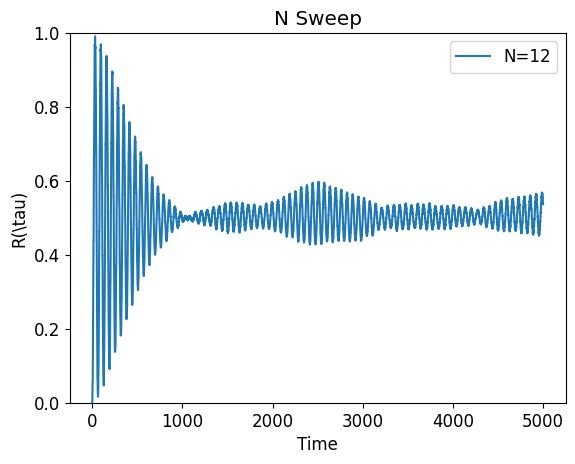

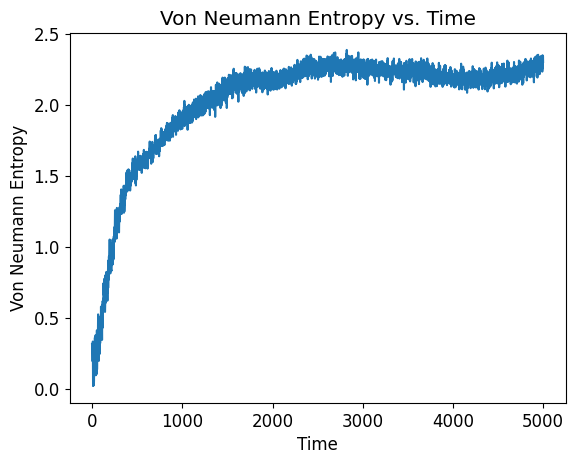

[0, 1, 8, 22, 56, 102, 171, 219, 265, 299, 313, 320, 321]


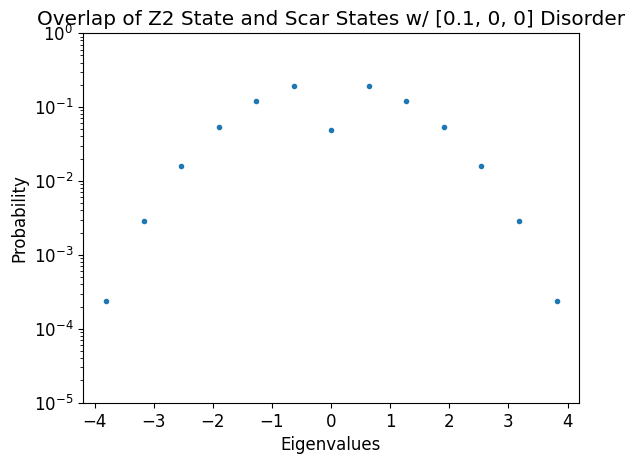

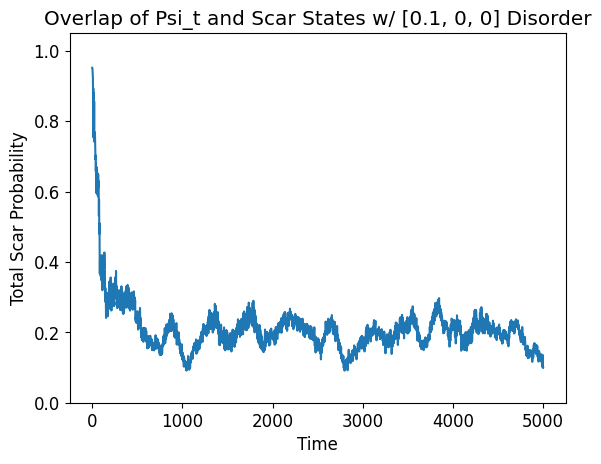

In [14]:
args = {"A": 0.1, "omega": wd}

H0_clean, _, _, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1(N, basisList)
H0, eigenvalues, eigenstates = get_dis_scar_ham(H0_clean, N, basisList, 
                                                ham_disorder=dis)
bandwidth = eigenvalues[-1] - eigenvalues[0]

H = qt.QobjEvo([H0, [H1, coeff]], args=args)
psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
Rtau_scar = np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
plt.plot(tlist, Rtau_scar, label=f"N={N}")

plt.title(f"N Sweep")
plt.xlabel("Time")
plt.ylabel(r"R(\tau)")
plt.legend()
plt.ylim(0, 1)
plt.show()

# max vn entrop (ln(dim of Hilbert space)=5.77)
vn_plot = plot_scar_vn_entrop(N, wd, tlist=tlist, disorder=dis, reals=1)

scarIndices, scarStates = giveMeScarOverlap(N, psi0, tlist, disorder=dis, plot_arc=True, reals=1, args=args)